<a href="https://colab.research.google.com/github/queirozcleiton/teste.py/blob/main/mine_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extração de dados

In [3]:
!pip install yfinance -q

import yfinance as yf

#Baixar dados de uma ação brasileira
acao = yf.Ticker("ITUB4.SA")

#Ver informaçoes gerais
info = acao.info
print("Empresa:", info.get("longName"))
print("Setor:", info.get("sector"))
print("Dididend Yield:", info.get("dividendYield"))


Empresa: Itaú Unibanco Holding S.A.
Setor: Financial Services
Dididend Yield: 2.31


In [4]:
#Histórico de dividendos
dividendos = acao.dividends
print(dividendos)

Date
2008-02-01 00:00:00-02:00    0.003507
2008-03-03 00:00:00-03:00    0.003507
2008-04-01 00:00:00-03:00    0.003507
2008-05-02 00:00:00-03:00    0.003507
2008-06-02 00:00:00-03:00    0.004384
                               ...   
2026-03-02 00:00:00-03:00    0.018182
2026-03-20 00:00:00-03:00    0.348880
2026-04-01 00:00:00-03:00    0.018182
2026-05-04 00:00:00-03:00    0.018182
2026-06-01 00:00:00-03:00    0.018182
Name: Dividends, Length: 271, dtype: float64


In [5]:
#Cotação dos últimos 12 meses
historico = acao.history(period="1y")
print(historico[["Close", "Volume"]].head(10))

                               Close    Volume
Date                                          
2025-06-03 00:00:00-03:00  32.921494  24216330
2025-06-04 00:00:00-03:00  32.841488  17784701
2025-06-05 00:00:00-03:00  32.441418  25542146
2025-06-06 00:00:00-03:00  32.521431  18733537
2025-06-09 00:00:00-03:00  32.352512  24664895
2025-06-10 00:00:00-03:00  32.302349  20974508
2025-06-11 00:00:00-03:00  32.598457  16665400
2025-06-12 00:00:00-03:00  32.849697  22525482
2025-06-13 00:00:00-03:00  32.454891  14821597
2025-06-16 00:00:00-03:00  33.047100  17874002


In [7]:
import yfinance as yf
import pandas as pd

acoes = ["ITUB4.SA", "BBSE3.SA", "TAEE11.SA", "VIVT3.SA", "EGIE3.SA"]

resultados = []

for ticker in acoes:
    acao = yf.Ticker(ticker)

    # Preço atual
    preco = acao.history(period="5d")["Close"].iloc[-1]

    # Dividendos pagos nos últimos 12 meses
    dividendos = acao.dividends
    dividendos.index = dividendos.index.tz_localize(None)
    um_ano_atras = pd.Timestamp.now() - pd.DateOffset(years=1)
    dy_valor = dividendos[dividendos.index >= um_ano_atras].sum()

    # DY calculado
    dy_pct = (dy_valor / preco) * 100

    resultados.append([ticker, round(preco, 2), round(dy_valor, 4), round(dy_pct, 2)])

df = pd.DataFrame(resultados, columns=["Ticker", "Preço R$", "Dividendos 12m", "DY %"])
df = df.sort_values("DY %", ascending=False)
print(df.to_string(index=False))

   Ticker  Preço R$  Dividendos 12m  DY %
 BBSE3.SA     35.04          4.5489 12.98
 ITUB4.SA     38.72          3.4108  8.81
TAEE11.SA     38.79          3.2754  8.44
 VIVT3.SA     33.75          2.4196  7.17
 EGIE3.SA     34.09          1.2054  3.54


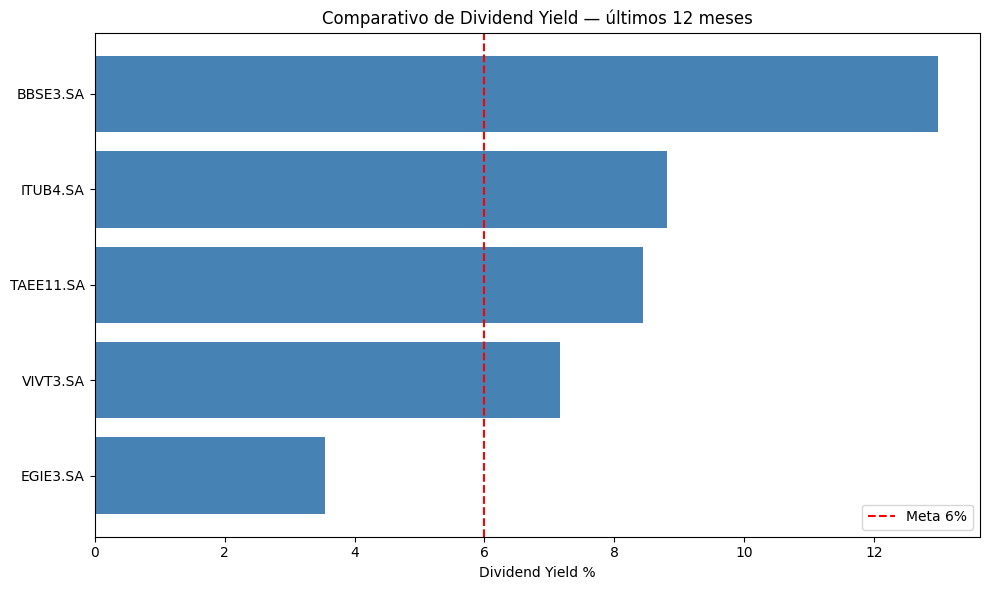

In [8]:
import matplotlib.pyplot as plt

df_plot = df.sort_values("DY %")

plt.figure(figsize=(10, 6))
plt.barh(df_plot["Ticker"], df_plot["DY %"], color="steelblue")
plt.xlabel("Dividend Yield %")
plt.title("Comparativo de Dividend Yield — últimos 12 meses")
plt.axvline(x=6, color="red", linestyle="--", label="Meta 6%")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
lista_acoes = [
    # Bancos
    "ITUB4.SA", "BBDC4.SA", "BBAS3.SA", "SANB11.SA",
    # Seguros
    "BBSE3.SA", "PSSA3.SA",
    # Energia elétrica
    "EGIE3.SA", "TAEE11.SA", "CPFE3.SA", "ENEV3.SA",
    # Telecom
    "VIVT3.SA",
    # Saneamento
    "SAPR11.SA", "CSMG3.SA",
    # Shoppings
    "MULT3.SA", "IGTI11.SA"
]

print(f"Total de ações para analisar: {len(lista_acoes)}")

Total de ações para analisar: 15


In [10]:
import yfinance as yf
import pandas as pd

# ==========================================
# SEUS CRITÉRIOS — ajuste conforme quiser
DY_MINIMO = 6.0       # Dividend Yield mínimo em %
DY_MAXIMO = 20.0      # Evita distorções
# ==========================================

resultados = []

for ticker in lista_acoes:
    try:
        acao = yf.Ticker(ticker)

        # Preço atual
        preco = acao.history(period="5d")["Close"].iloc[-1]

        # Dividendos últimos 12 meses
        dividendos = acao.dividends
        dividendos.index = dividendos.index.tz_localize(None)
        um_ano_atras = pd.Timestamp.now() - pd.DateOffset(years=1)
        dy_valor = dividendos[dividendos.index >= um_ano_atras].sum()

        # DY calculado
        dy_pct = (dy_valor / preco) * 100

        # Aplicar filtros
        if DY_MINIMO <= dy_pct <= DY_MAXIMO:
            resultados.append([ticker, round(preco, 2), round(dy_valor, 4), round(dy_pct, 2)])

    except Exception as e:
        print(f"{ticker}: erro ao buscar dados")

# Montar DataFrame
df_screener = pd.DataFrame(resultados, columns=["Ticker", "Preço R$", "Dividendos 12m", "DY %"])
df_screener = df_screener.sort_values("DY %", ascending=False).reset_index(drop=True)

print(f"Ações que passaram no filtro: {len(df_screener)}\n")
print(df_screener.to_string(index=False))

Ações que passaram no filtro: 8

   Ticker  Preço R$  Dividendos 12m  DY %
 BBSE3.SA     35.04          4.5489 12.98
 ITUB4.SA     38.72          3.4108  8.81
 BBDC4.SA     17.37          1.5057  8.67
SANB11.SA     26.72          2.3084  8.64
 CPFE3.SA     43.30          3.7315  8.62
TAEE11.SA     38.79          3.2754  8.44
 VIVT3.SA     33.75          2.4196  7.17
 PSSA3.SA     48.16          2.9830  6.19


In [11]:
# Salvar o resultado do screener em Excel
df_screener.to_excel("screener_dividendos.xlsx", index=False)
print("Planilha salva!")

# Baixar
from google.colab import files
files.download("screener_dividendos.xlsx")

Planilha salva!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

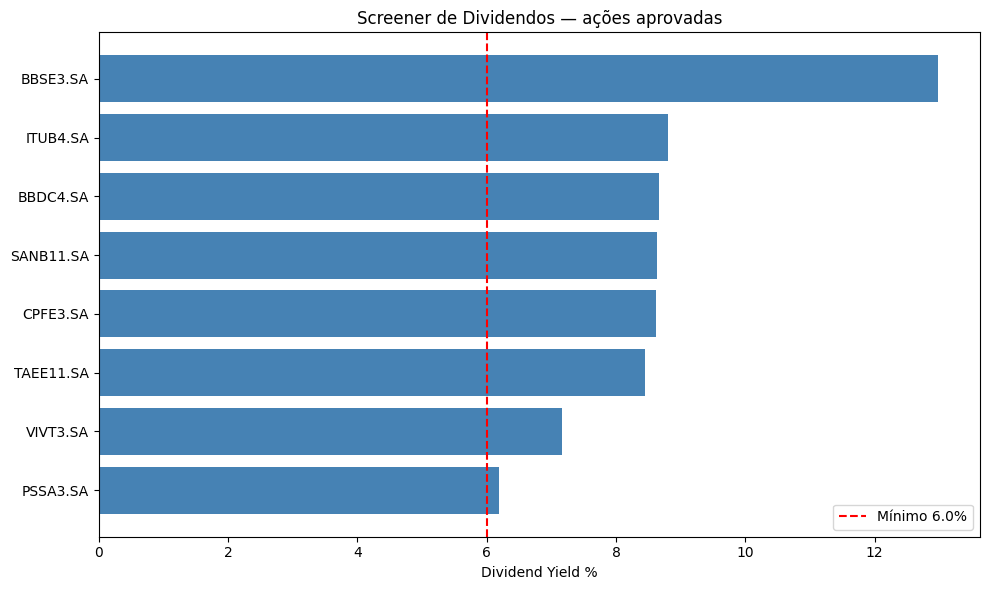

In [12]:
import matplotlib.pyplot as plt

df_plot = df_screener.sort_values("DY %")

plt.figure(figsize=(10, 6))
bars = plt.barh(df_plot["Ticker"], df_plot["DY %"], color="steelblue")
plt.xlabel("Dividend Yield %")
plt.title("Screener de Dividendos — ações aprovadas")
plt.axvline(x=DY_MINIMO, color="red", linestyle="--", label=f"Mínimo {DY_MINIMO}%")
plt.legend()
plt.tight_layout()
plt.show()